In [ ]:
!pip install tensorflow opencv-python pytesseract faker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 27.8 MB/s eta 0:00:00


In [ ]:
!apt-get install tesseract-ocr
!tesseract --version

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
tesseract 4.1.1
 leptonica-1.82.0
  libgif 5.1.9 : libjpeg 8d (libjpeg-turbo 2.1.1) : libpng 1.6.37 : libtiff 4.3.0 : zlib 1.2.11 : libwebp 1.2.2 : libopenjp2 2.4.0
 Found AVX2
 Found AVX
 Found FMA
 Found SSE
 Found libarchive 3.6.0 zlib/1.2.11 liblzma/5.2.5 bz2lib/1.0.8 liblz4/1.9.3 libzstd/1.4.8


In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import os
import pytesseract
from PIL import Image, ImageDraw
from faker import Faker
import matplotlib.pyplot as plt

In [ ]:
import os

os.makedirs("dataset/train/real", exist_ok=True)
os.makedirs("dataset/train/fake", exist_ok=True)

print("Folders created")

Folders created


In [ ]:
!pip install faker

In [ ]:
import random
from faker import Faker
from PIL import Image, ImageDraw, ImageFont
import numpy as np

In [ ]:
def create_logo():

    logo = Image.new("RGB",(120,120),"white")
    draw = ImageDraw.Draw(logo)

    color = random.choice(["blue","green","purple"])

    draw.rectangle((20,20,100,100),outline=color,width=5)

    draw.text((35,45),"AI",fill=color)

    return logo


In [ ]:
def create_signature():

    sign = Image.new("RGB",(200,80),"white")
    draw = ImageDraw.Draw(sign)

    name = random.choice(["Director","HR","Manager"])

    draw.line((10,40,180,30),fill="black",width=3)

    draw.text((50,45),name,fill="black")

    return sign

In [ ]:
fake = Faker()

def generate_certificate():

    width = 1000
    height = 700

    img = Image.new("RGB",(width,height),"white")
    draw = ImageDraw.Draw(img)

    logo = create_logo()
    signature = create_signature()

    img.paste(logo,(50,50))
    img.paste(signature,(700,550))

    name = fake.name()

    company = random.choice([
        "TechNova Pvt Ltd",
        "FutureAI Systems",
        "NextGen Technologies"
    ])

    course = random.choice([
        "Data Science Internship",
        "Machine Learning Internship",
        "Artificial Intelligence Internship"
    ])

    grade = random.choice(["A","A+","B+","A-"])

    text = f"""
    INTERNSHIP CERTIFICATE

    This is to certify that

    {name}

    has successfully completed

    {course}

    at

    {company}

    Grade : {grade}
    """

    draw.text((200,200),text,fill="black")

    return img

In [ ]:
def tamper_certificate(img):

    draw = ImageDraw.Draw(img)

    tamper_type = random.choice(["grade","name","color"])

    if tamper_type == "grade":
        draw.text((550,420),"Grade : A++",fill="red")

    elif tamper_type == "name":
        draw.text((300,300),"Edited Name",fill="red")

    elif tamper_type == "color":
        draw.rectangle((180,380,800,460),outline="red",width=4)

    return img

In [ ]:
total_images = 1000

for i in range(total_images):

    real_img = generate_certificate()
    real_img.save(f"dataset/train/real/real_{i}.png")

    fake_img = generate_certificate()
    fake_img = tamper_certificate(fake_img)
    fake_img.save(f"dataset/train/fake/fake_{i}.png")

print("Realistic dataset generated")

Realistic dataset generated


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(rescale=1./255)

train_data = datagen.flow_from_directory(
    "dataset/train",
    target_size=(224,224),
    batch_size=16,
    class_mode="binary"
)

Found 2000 images belonging to 2 classes.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()

model.add(Conv2D(32,(3,3),activation="relu",input_shape=(224,224,3)))
model.add(MaxPooling2D())

model.add(Conv2D(64,(3,3),activation="relu"))
model.add(MaxPooling2D())

model.add(Conv2D(128,(3,3),activation="relu"))
model.add(MaxPooling2D())

model.add(Flatten())

model.add(Dense(128,activation="relu"))
model.add(Dropout(0.5))

model.add(Dense(1,activation="sigmoid"))

model.compile(
optimizer="adam",
loss="binary_crossentropy",
metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_data,
    epochs=10
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 211s 2s/step - accuracy: 0.6653 - loss: 0.6240
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 207s 2s/step - accuracy: 1.0000 - loss: 8.4944e-04
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 217s 2s/step - accuracy: 1.0000 - loss: 3.0438e-04
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 214s 2s/step - accuracy: 1.0000 - loss: 7.9971e-05
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 214s 2s/step - accuracy: 1.0000 - loss: 3.3105e-05
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 226s 2s/step - accuracy: 1.0000 - loss: 3.1000e-05
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 211s 2s/step - accuracy: 1.0000 - loss: 2.5443e-05
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 258s 2s/step - accuracy: 1.0000 - loss: 2.2995e-05
Epoch 9/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 274s 2s/step - accuracy: 1.0000 - loss: 9.9271e-06
Epoch 10/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 212s 2s/step - accuracy: 1.0000 - loss: 1.0074e-05


In [ ]:
model.save("fraud_model.h5")

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving fake_1.png to fake_1.png


In [ ]:
img_path = list(uploaded.keys())[0]

img = cv2.imread(img_path)
img2 = cv2.resize(img,(224,224))/255.0
img2 = np.reshape(img2,(1,224,224,3))

prediction = model.predict(img2)

if prediction[0][0] > 0.5:
    print("Fake Document Detected")
else:
    print("Real Document")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
Fake Document Detected


In [ ]:
!apt-get install poppler-utils

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
poppler-utils is already the newest version (22.02.0-2ubuntu0.12).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [ ]:
!pip install pdf2image

In [ ]:
from pdf2image import convert_from_path

# Assuming `img_path` is the path to your PDF file
pages = convert_from_path(img_path, 200) # 200 DPI for better quality

# Take the first page of the PDF as the image for prediction
# You might want to iterate through all pages or choose a specific one
img_pil = pages[0]

# Convert PIL Image to OpenCV format
img_np = np.array(img_pil)
img = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)

# The rest of the original code
img2 = cv2.resize(img, (224, 224)) / 255.0
img2 = np.reshape(img2, (1, 224, 224, 3))

prediction = model.predict(img2)

if prediction[0][0] > 0.5:
    print("Fake Document Detected")
else:
    print("Real Document")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
Real Document


In [ ]:
text = pytesseract.image_to_string(img)

print("Extracted OCR Text:\n")
print(text)

Extracted OCR Text:

INTERNSHIPCERTIFICATE
Thisis tocertity that
Michael Moore
hassuccessfully completed

Data Science Internship

at

 

Director



(np.float64(-0.5), np.float64(999.5), np.float64(699.5), np.float64(-0.5))

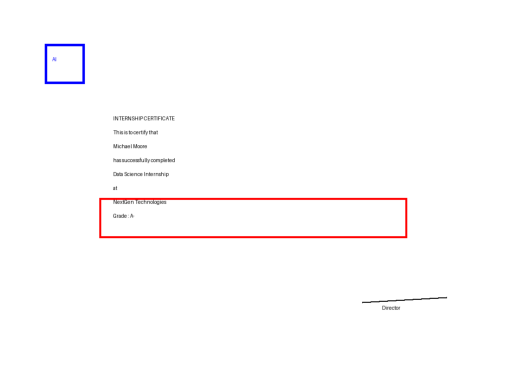

In [ ]:
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")



*    Upload Document
      ↓
Image Resize
      ↓
CNN Model
      ↓
Real / Fake Prediction
      ↓
OCR Text Extractionitem


